In [ ]:
# 1 Prüfkriterien
# 1.1 für Übersetzung:
#   - semantische Äquvalenz zum Original
#   - (korrekte Übersetzung von Fachbegriffen)
#   - vergleichbare Länge der Fragen

# 1.2 Schlüsselbegriffe
#   - Vorhandensein in Musterlösung
#   - Kerninhalte abgedeckt?
#   - Konsistenz bei ähnlichen Fragen

# 1.3 Punktvergabe
#   - entspricht die Punktvergabe der Komplexität
#   - sind Aufzählungsfragen konsistent niedriger bewertet?
#   - Wurde die maximal Punktzahl beachtet? Gibt es Ausreißer?

# 2 Visualisierung + Herausfiltern von Auffälligkeiten

# 3 dokumentierte Bereinigung

# 4 Bereinigte CSV erzeugen

In [ ]:
# Datei einlesen & Aufbau Tabelle prüfen

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer

path = "./generated_q_and_a_new.csv"
df = pd.read_csv(path)

df.head()

/home/project/EchoLearn/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,Unnamed: 0,question,answer,max_points,keywords,classification,original_question,original_answer
0,0,Was ist Data Science?,"Data Science ist ein interdisziplinäres Feld, ...",6,interdisziplinär; wissenschaftliche Methoden; ...,Hauptfrage,What is data science?,Data science is an interdisciplinary field tha...
1,1,Welche sind die Schlüsselschritte im Data-Scie...,Die Schlüsselschritte umfassen typischerweise ...,4,Problemdefinition; Datensammlung; Datenbereini...,Aufzählung,What are the key steps in the data science pro...,The key steps typically include problem defini...
2,2,Was ist der Unterschied zwischen überwachtem u...,Überwachtes Lernen beinhaltet das Trainieren e...,6,überwachtes Lernen; unüberwachtes Lernen; gela...,Hauptfrage,What is the difference between supervised and ...,Supervised learning involves training a model ...
3,3,Erkläre das Bias-Variance-Trade-off.,Das Bias-Variance-Trade-off ist der Kompromiss...,6,Bias-Variance-Trade-off; Bias; Variance; Unter...,Hauptfrage,Explain the bias-variance tradeoff.,The bias-variance tradeoff is the balance betw...
4,4,Was ist Feature Engineering?,"Feature Engineering ist der Prozess, Features ...",6,Feature Engineering; Rohdaten; Auswahl; Transf...,Hauptfrage,What is feature engineering?,Feature engineering is the process of selectin...


In [ ]:
# Spaltennamen sprechende Namen geben & auf fehlende Datenpunkte prüfen
df.columns = [
    "id",
    "question_de",
    "answer_de",
    "max_points",
    "keywords",
    "question_type",
    "question_en",
    "answer_en",
]

df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   id             200 non-null    int64 
 1   question_de    200 non-null    object
 2   answer_de      200 non-null    object
 3   max_points     200 non-null    int64 
 4   keywords       200 non-null    object
 5   question_type  200 non-null    object
 6   question_en    200 non-null    object
 7   answer_en      200 non-null    object
dtypes: int64(2), object(6)
memory usage: 12.6+ KB


,id,question_de,answer_de,max_points,keywords,question_type,question_en,answer_en
0,0,Was ist Data Science?,"Data Science ist ein interdisziplinäres Feld, ...",6,interdisziplinär; wissenschaftliche Methoden; ...,Hauptfrage,What is data science?,Data science is an interdisciplinary field tha...
1,1,Welche sind die Schlüsselschritte im Data-Scie...,Die Schlüsselschritte umfassen typischerweise ...,4,Problemdefinition; Datensammlung; Datenbereini...,Aufzählung,What are the key steps in the data science pro...,The key steps typically include problem defini...
2,2,Was ist der Unterschied zwischen überwachtem u...,Überwachtes Lernen beinhaltet das Trainieren e...,6,überwachtes Lernen; unüberwachtes Lernen; gela...,Hauptfrage,What is the difference between supervised and ...,Supervised learning involves training a model ...
3,3,Erkläre das Bias-Variance-Trade-off.,Das Bias-Variance-Trade-off ist der Kompromiss...,6,Bias-Variance-Trade-off; Bias; Variance; Unter...,Hauptfrage,Explain the bias-variance tradeoff.,The bias-variance tradeoff is the balance betw...
4,4,Was ist Feature Engineering?,"Feature Engineering ist der Prozess, Features ...",6,Feature Engineering; Rohdaten; Auswahl; Transf...,Hauptfrage,What is feature engineering?,Feature engineering is the process of selectin...


In [ ]:
# Semantische Ähnlichkeit der Fragen prüfen

model = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")

emb_en = model.encode(df["question_en"].tolist(), show_progress_bar=True)
emb_de = model.encode(df["question_de"].tolist(), show_progress_bar=True)

df["translation_similarity_question"] = [
    cosine_similarity([e], [d])[0][0] for e, d in zip(emb_en, emb_de)
]

Batches: 100%|██████████| 7/7 [00:01<00:00,  4.53it/s]


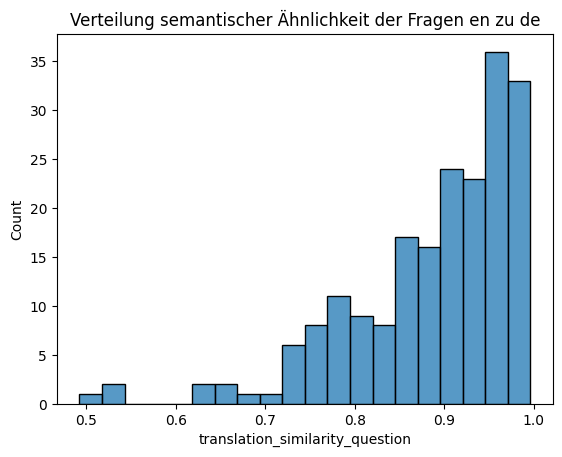

In [ ]:
sns.histplot(df["translation_similarity_question"], bins=20)
plt.title("Verteilung semantischer Ähnlichkeit der Fragen en zu de")
plt.show()

Batches: 100%|██████████| 7/7 [00:04<00:00,  1.61it/s]


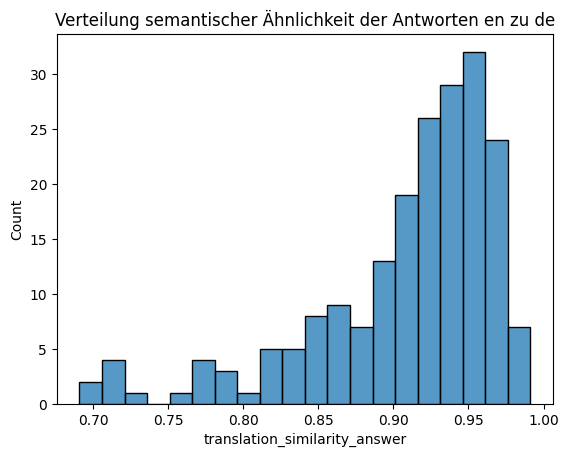

In [ ]:
# semantische Ähnlichkeit der Antworten darstellen

emb_en = model.encode(df["answer_en"].tolist(), show_progress_bar=True)
emb_de = model.encode(df["answer_de"].tolist(), show_progress_bar=True)

df["translation_similarity_answer"] = [
    cosine_similarity([e], [d])[0][0] for e, d in zip(emb_en, emb_de)
]

sns.histplot(df["translation_similarity_answer"], bins=20)
plt.title("Verteilung semantischer Ähnlichkeit der Antworten en zu de")
plt.show()

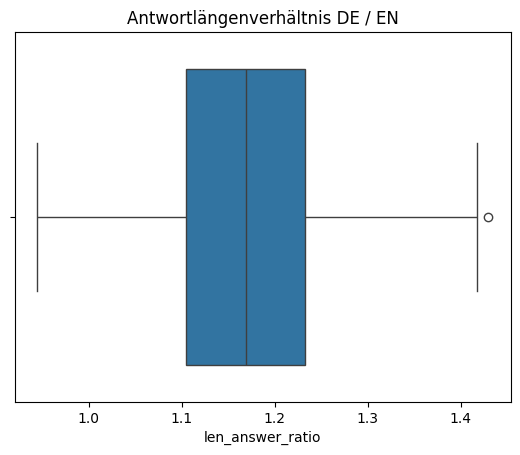

In [ ]:
# Vergleich der Antwortlängen

df["len_answer_en"] = df["answer_en"].str.len()
df["len_answer_de"] = df["answer_de"].str.len()
df["len_answer_ratio"] = df["len_answer_de"] / df["len_answer_en"]

sns.boxplot(x=df["len_answer_ratio"])
plt.title("Antwortlängenverhältnis DE / EN")
plt.show()

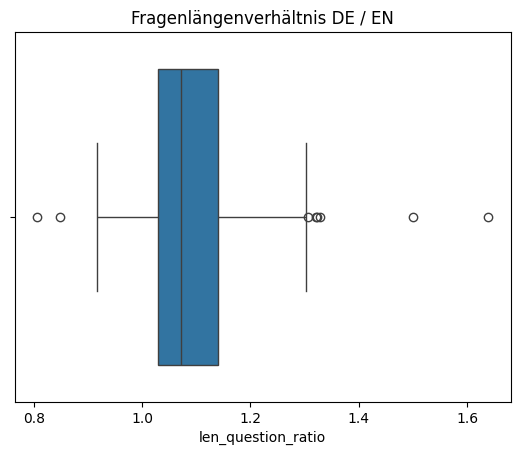

In [ ]:
# Vergleich der Längen der Fragen

df["len_question_en"] = df["question_en"].str.len()
df["len_question_de"] = df["question_de"].str.len()
df["len_question_ratio"] = df["len_question_de"] / df["len_question_en"]

sns.boxplot(x=df["len_question_ratio"])
plt.title("Fragenlängenverhältnis DE / EN")
plt.show()

<Axes: xlabel='answer_length', ylabel='max_points'>

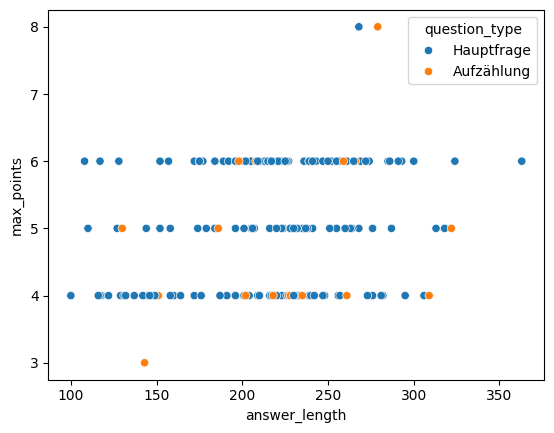

In [ ]:
# Konstitenz der Punkte zur Antwortkomplexität überprüfen

df["answer_length"] = df["answer_en"].str.len()

sns.scatterplot(data=df, x="answer_length", y="max_points", hue="question_type")

In [ ]:
# Statistische Ausreiser notieren

df["points_z"] = (df["max_points"] - df["max_points"].mean()) / df["max_points"].std()

In [ ]:
# Datensatz mit zu untersuchenden Daten erstellen

df["to_review"] = (
    (df["translation_similarity_answer"] < 0.75)
    | (df["translation_similarity_question"] < 0.75)
    | (df["len_answer_ratio"] < 0.5)
    | (df["len_answer_ratio"] > 2.0)
    | (df["len_question_ratio"] < 0.5)
    | (df["len_question_ratio"] > 2.0)
    | (df["points_z"].abs() > 2)
)

review_df = df[df["to_review"]]
review_df[
    [
        "id",
        "translation_similarity_answer",
        "translation_similarity_question",
        "len_answer_ratio",
        "len_question_ratio",
        "max_points",
        "points_z",
    ]
].head(30)

,id,translation_similarity_answer,translation_similarity_question,len_answer_ratio,len_question_ratio,max_points,points_z
8,8,0.930549,0.855998,1.069930,1.283333,3,-2.194753
16,16,0.800587,0.732220,1.052326,1.055556,4,-1.134486
17,17,0.712090,0.762461,1.078261,1.038462,4,-1.134486
20,20,0.784226,0.619923,0.991379,0.972973,4,-1.134486
21,21,0.850130,0.658511,1.137931,1.058824,4,-1.134486
31,31,0.876583,0.746244,1.193750,0.806452,4,-1.134486
33,33,0.750966,0.526215,1.354497,0.958333,6,0.986049
67,67,0.718413,0.826101,1.086957,1.078947,4,-1.134486
74,74,0.690732,0.899834,1.037879,1.121622,5,-0.074219
77,77,0.695197,0.651981,1.089385,1.017241,5,-0.074219


In [ ]:
# Aufteilung Datensätze für Evaluation
# 10 Fragen, die alle gleich haben
# Sandra untersucht extra die korrigierten Datensätze
# 22 Datensätze nur Aleks
# 22 Datensätze nur Maurice
# 21 Datensätze nur Sandra
# ergibt 95 evaluierte Datensätze
all = [3, 5, 14, 22, 28, 35, 39, 42, 47, 49]
df_all = df[df["id"].isin(all)].copy()
# df_all.to_csv("evaluation_all.csv")

aleks = [
    52,
    54,
    56,
    57,
    59,
    63,
    66,
    68,
    69,
    71,
    72,
    75,
    78,
    80,
    83,
    84,
    86,
    91,
    92,
    94,
    95,
    99,
]
df_aleks = df[df["id"].isin(aleks)].copy()
# df_aleks.to_csv("evaluation_aleks.csv")

maurice = [
    101,
    102,
    105,
    109,
    111,
    114,
    118,
    119,
    122,
    123,
    126,
    127,
    130,
    134,
    135,
    138,
    139,
    140,
    144,
    146,
    147,
    150,
]
df_maurice = df[df["id"].isin(maurice)].copy()
# df_maurice.to_csv("evaluation_maurice.csv")

sandra = [
    152,
    154,
    156,
    157,
    161,
    163,
    164,
    167,
    168,
    171,
    172,
    174,
    176,
    180,
    183,
    184,
    186,
    189,
    191,
    196,
    197,
]
df_sandra = df[df["id"].isin(sandra)].copy()
df_sandra.to_csv("evaluation_sandra.csv")

In [ ]:
# Vorhandensein der Schlüsselbegriffe in den Antworten --> noch nicht lauffähig!

# def keyword_coverage(answer, keywords):
# if k.strip():
# for k in keywords.split(",")
# keyword_list = [k.strip().lower()]
# if not keyword_list:
# return 0.0
# return np.mean([kw in answer.lower() for kw in keyword_list])
# keyword_list = [k.strip().lower() for k in keywords.split(",")
#               if k.strip()] else keyword_list:
# return 0.0
# return np.mean([kw in answer.lower() for kw in keyword_list])

# df["keyword_coverage"] = df.apply(
# lambda r: keyword_coverage(["answer_en"],r["keywords"]), axis = 1)

NameError: name 'k' is not defined